# SyntheSize Integration Examples in SyNG-BTS

This notebook demonstrates the two main synthesize functions in SyNG-BTS:
- `evaluate_sample_sizes`
- `plot_sample_sizes`

It uses:
- Real bundled data: `BRCASubtypeSel_test`
- Bundled generated data: `BRCASubtypeSel_train_epoch285_CVAE1-20_generated`
- Newly generated CVAE data from `BRCASubtypeSel_train`

## 1) Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from syng_bts import (
    evaluate_sample_sizes,
    plot_sample_sizes,
    resolve_data,
    generate,
    list_bundled_datasets,
)

np.random.seed(42)

## 2) Load real and bundled generated BRCA subtype datasets

In [2]:
# List available bundled datasets
print(list_bundled_datasets())

real_df, real_groups = resolve_data("BRCASubtypeSel_test")
gen_df_bundled, gen_groups_bundled = resolve_data(
    "BRCASubtypeSel_train_epoch285_CVAE1-20_generated"
)

print("Real data shape:", real_df.shape)
print("Real groups size:", None if real_groups is None else len(real_groups))
# print unique group labels if available
if real_groups is not None:
    print("Real group labels:", list(set(real_groups)))
print("Bundled generated data shape:", gen_df_bundled.shape)
print(
    "Bundled generated groups size:",
    None if gen_groups_bundled is None else len(gen_groups_bundled),
)
if gen_groups_bundled is not None:
    print("Bundled generated group labels:", list(set(gen_groups_bundled)))

['SKCMPositive_4', 'BRCA', 'PRAD', 'BRCASubtypeSel', 'BRCASubtypeSel_test', 'BRCASubtypeSel_train', 'BRCASubtypeSel_train_epoch285_CVAE1-20_generated', 'LIHCSubtypeFamInd', 'LIHCSubtypeFamInd_DESeq', 'LIHCSubtypeFamInd_test74', 'LIHCSubtypeFamInd_test74_DESeq', 'LIHCSubtypeFamInd_train294', 'LIHCSubtypeFamInd_train294_DESeq']
Real data shape: (200, 47)
Real groups size: 200
Real group labels: ['Infiltrating Ductal Carcinoma', 'Infiltrating Lobular Carcinoma']
Bundled generated data shape: (1000, 47)
Bundled generated groups size: 1000
Bundled generated group labels: ['Infiltrating Ductal Carcinoma', 'Infiltrating Lobular Carcinoma']


In [3]:
print("Real group distribution:")
print(pd.Series(real_groups).value_counts(dropna=False))
print()
print("Bundled generated group distribution:")
print(pd.Series(gen_groups_bundled).value_counts(dropna=False))

Real group distribution:
groups
Infiltrating Lobular Carcinoma    100
Infiltrating Ductal Carcinoma     100
Name: count, dtype: int64

Bundled generated group distribution:
groups
Infiltrating Lobular Carcinoma    500
Infiltrating Ductal Carcinoma     500
Name: count, dtype: int64


## 3) Run `evaluate_sample_sizes` on real vs bundled generated data

For a quick notebook runtime, this example uses two classifiers (`LOGIS`, `RF`) and 2 draws.
To evaluate all methods, set `methods=None`.

In [4]:
sample_sizes = list(np.arange(20, 201, 10))

methods = ["LOGIS", "RF"]

metrics_real = evaluate_sample_sizes(
    data=real_df,
    sample_sizes=sample_sizes,
    groups=real_groups,
    n_draws=2,
    methods=methods,
    apply_log=True,
)

metrics_gen_bundled = evaluate_sample_sizes(
    data=gen_df_bundled,
    sample_sizes=sample_sizes,
    groups=gen_groups_bundled,
    n_draws=2,
    methods=methods,
    apply_log=True,
)

display(metrics_real.head())
display(metrics_gen_bundled.head())

Progress |████████████████████| 76/76 size=19/19 (n=200), draw=1, method=RFGIS
Progress |████████████████████| 76/76 size=19/19 (n=200), draw=1, method=RFGIS


,total_size,draw,method,f1_score,accuracy,auc
0,20,0,LOGIS,0.900000,0.90,0.950000
1,20,0,RF,0.793333,0.80,0.900000
2,20,1,LOGIS,0.646667,0.65,0.750000
3,20,1,RF,0.746667,0.75,0.825000
4,30,0,LOGIS,0.596190,0.60,0.688889


,total_size,draw,method,f1_score,accuracy,auc
0,20,0,LOGIS,0.800000,0.80,0.900000
1,20,0,RF,0.793333,0.80,0.825000
2,20,1,LOGIS,0.746667,0.75,0.800000
3,20,1,RF,0.426667,0.45,0.450000
4,30,0,LOGIS,0.695238,0.70,0.777778


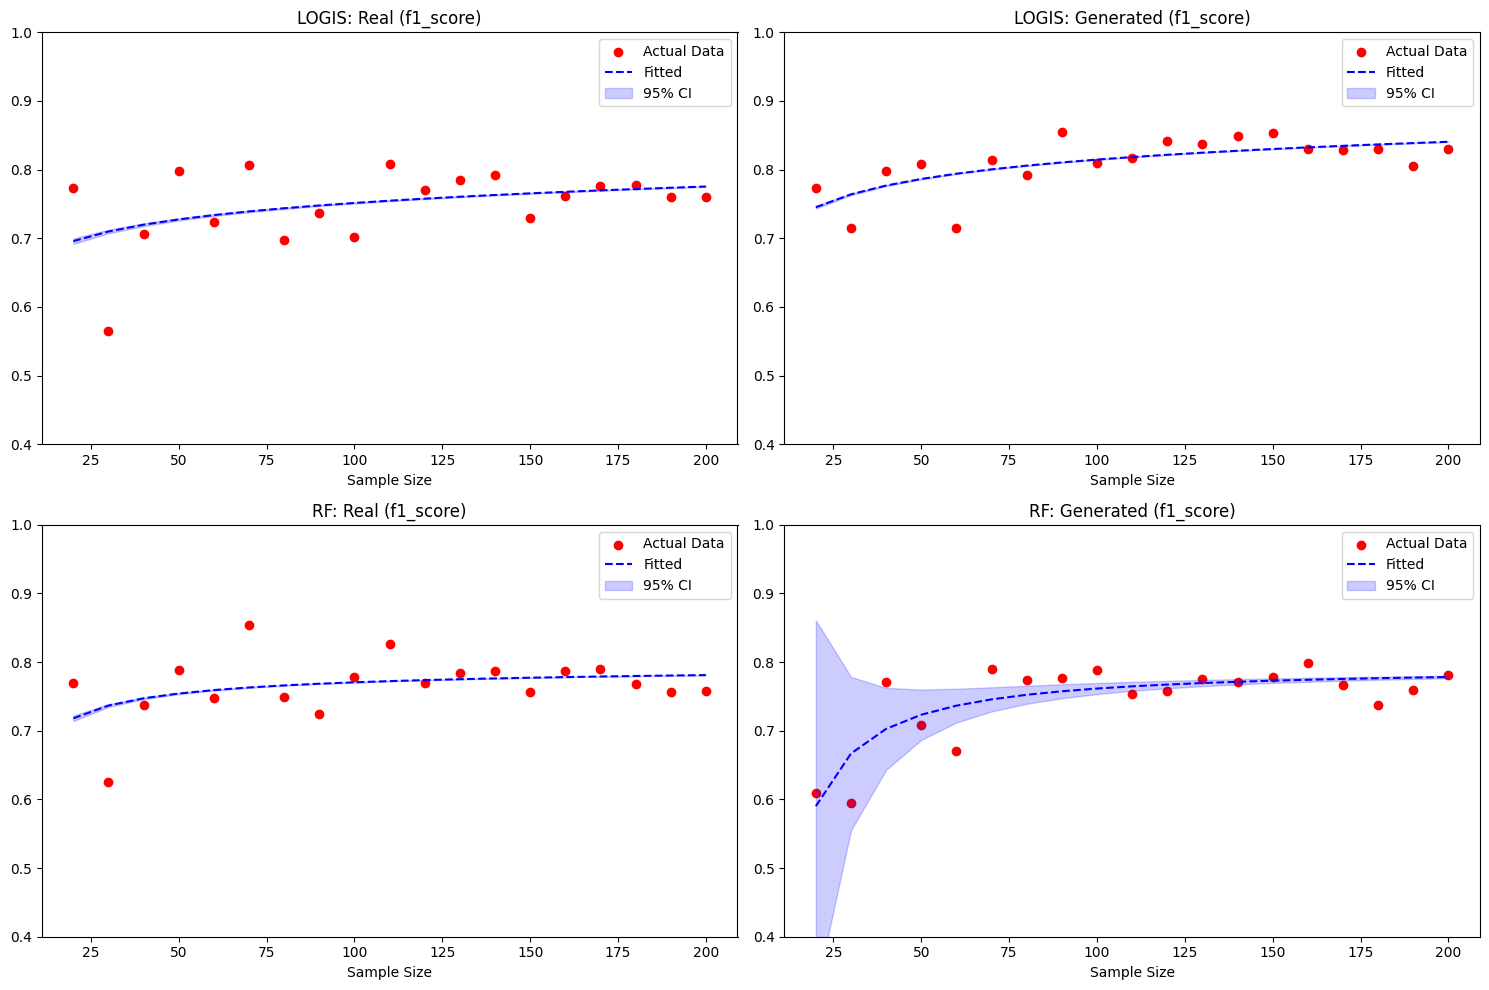

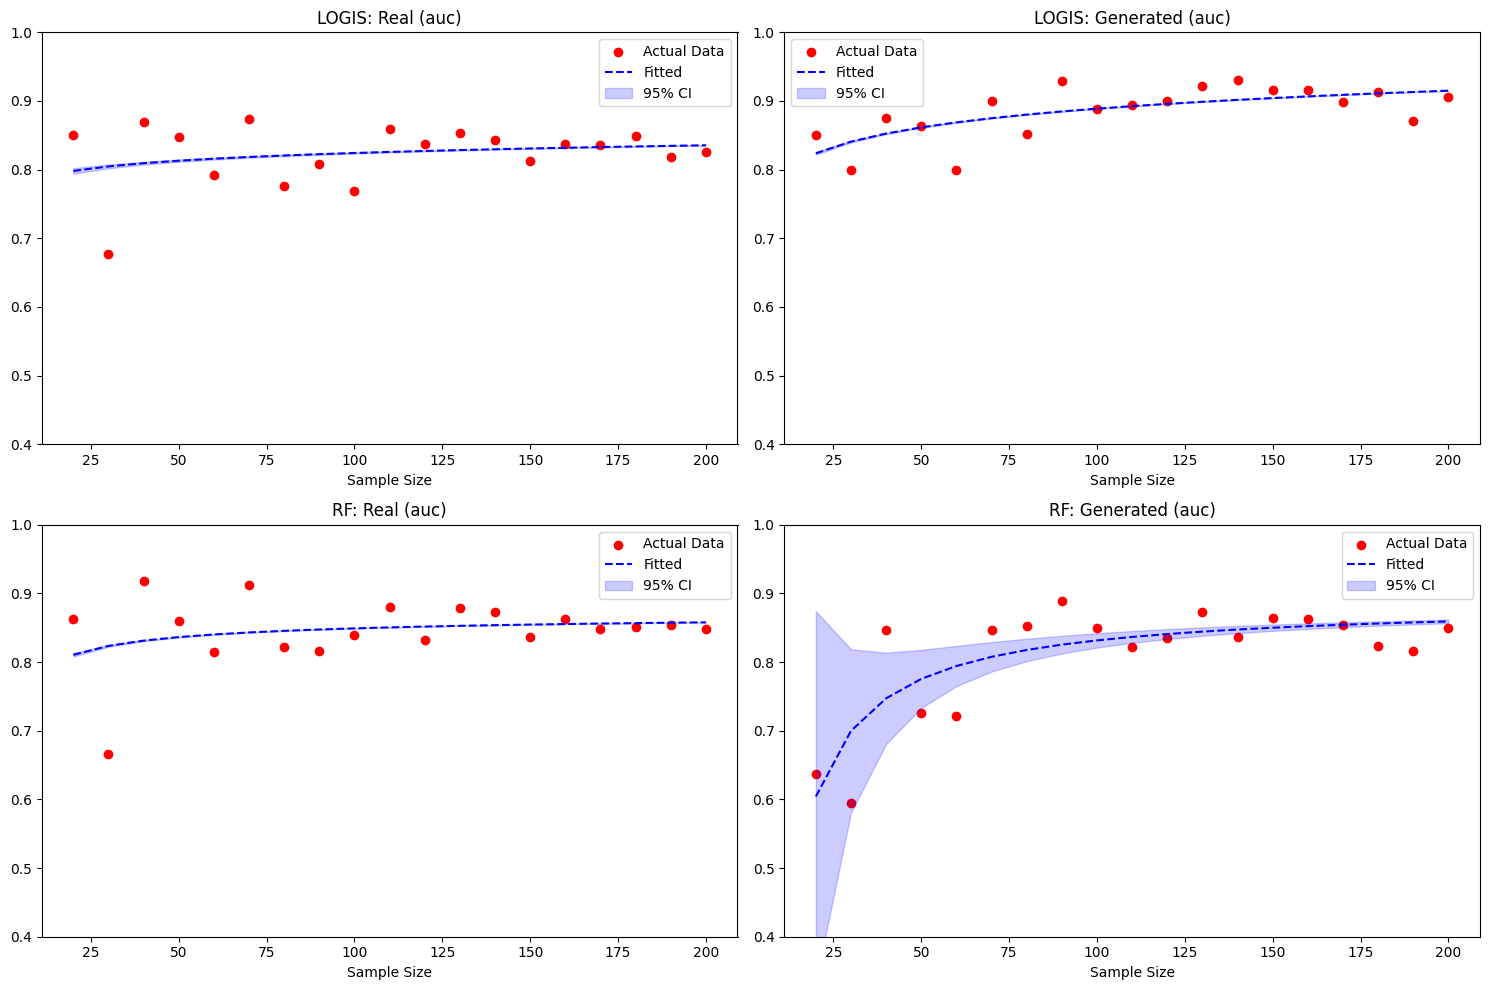

In [5]:
# Compare learning curves (real vs bundled generated)
fig_f1 = plot_sample_sizes(
    metric_real=metrics_real,
    metric_generated=metrics_gen_bundled,
    n_target=200,
    metric_name="f1_score",
)
plt.show()

fig_auc = plot_sample_sizes(
    metric_real=metrics_real,
    metric_generated=metrics_gen_bundled,
    n_target=200,
    metric_name="auc",
)
plt.show()

## 4) Generate new synthetic data with CVAE, then evaluate with synthesize

This demonstrates the SyngResult workflow: run `generate(...)` and pass the result directly to `evaluate_sample_sizes(...)`.

In [ ]:
# Keep epochs modest for a notebook demo runtime
cvae_result = generate(
    data="BRCASubtypeSel_train",
    model="CVAE1-20",
    new_size=1000,
    epoch=500,
    early_stop_patience=100,
    apply_log=True,
    random_seed=42,
    verbose="minimal",
)

print("Generated data shape:", cvae_result.generated_data.shape)
print(
    "Original data shape:",
    None if cvae_result.original_data is None else cvae_result.original_data.shape,
)
print("Group counts table:")
print("Original groups (cvae_result.original_groups):")
print(cvae_result.original_groups.value_counts())
print()
print("Generated groups (cvae_result.generated_groups):")
print(cvae_result.generated_groups.value_counts())
print()

Starting training: 500 epochs, loss=MSE, kl_weight=20, early_stop=100
Epoch   3/500 |░░░░░░░░░░░░░░░░░░░░| kl: 1.1658, recons: 3824.9922, val: 4452.2794

Epoch 320/500 |████████████░░░░░░░░| kl: 0.6874, recons: 69.7538, val: 77.66700793
Early stopping at epoch 220 (best val_loss: 73.9230)
Training complete: 0.20min
Generated data shape: (1000, 47)
Original data shape: (881, 47)
Generated groups available: True
Original groups available: True
group
Infiltrating Ductal Carcinoma     875
Infiltrating Lobular Carcinoma    125
Name: count, dtype: int64
group
Infiltrating Ductal Carcinoma     771
Infiltrating Lobular Carcinoma    110
Name: count, dtype: int64


Progress |████████████████████| 90/90 size=9/9 (n=500), draw=4, method=RFGIS


/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:273: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:292: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:273: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/prepro

Progress |░░░░░░░░░░░░░░░░░░░░| 2/90 size=1/9 (n=100), draw=0, method=RFGIS

/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:273: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:292: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:273: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/prepro

Progress |░░░░░░░░░░░░░░░░░░░░| 4/90 size=1/9 (n=100), draw=1, method=RFGIS

...

Progress |███████████████████░| 86/90 size=9/9 (n=500), draw=2, method=RFGIS

/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:273: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:292: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:273: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/prepro

Progress |███████████████████░| 88/90 size=9/9 (n=500), draw=3, method=RFGIS

/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:273: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:292: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:273: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/yannick/GoogleDrive/projects/SyNG-BTS/.venv/lib/python3.13/site-packages/sklearn/prepro

Progress |████████████████████| 90/90 size=9/9 (n=500), draw=4, method=RFGIS


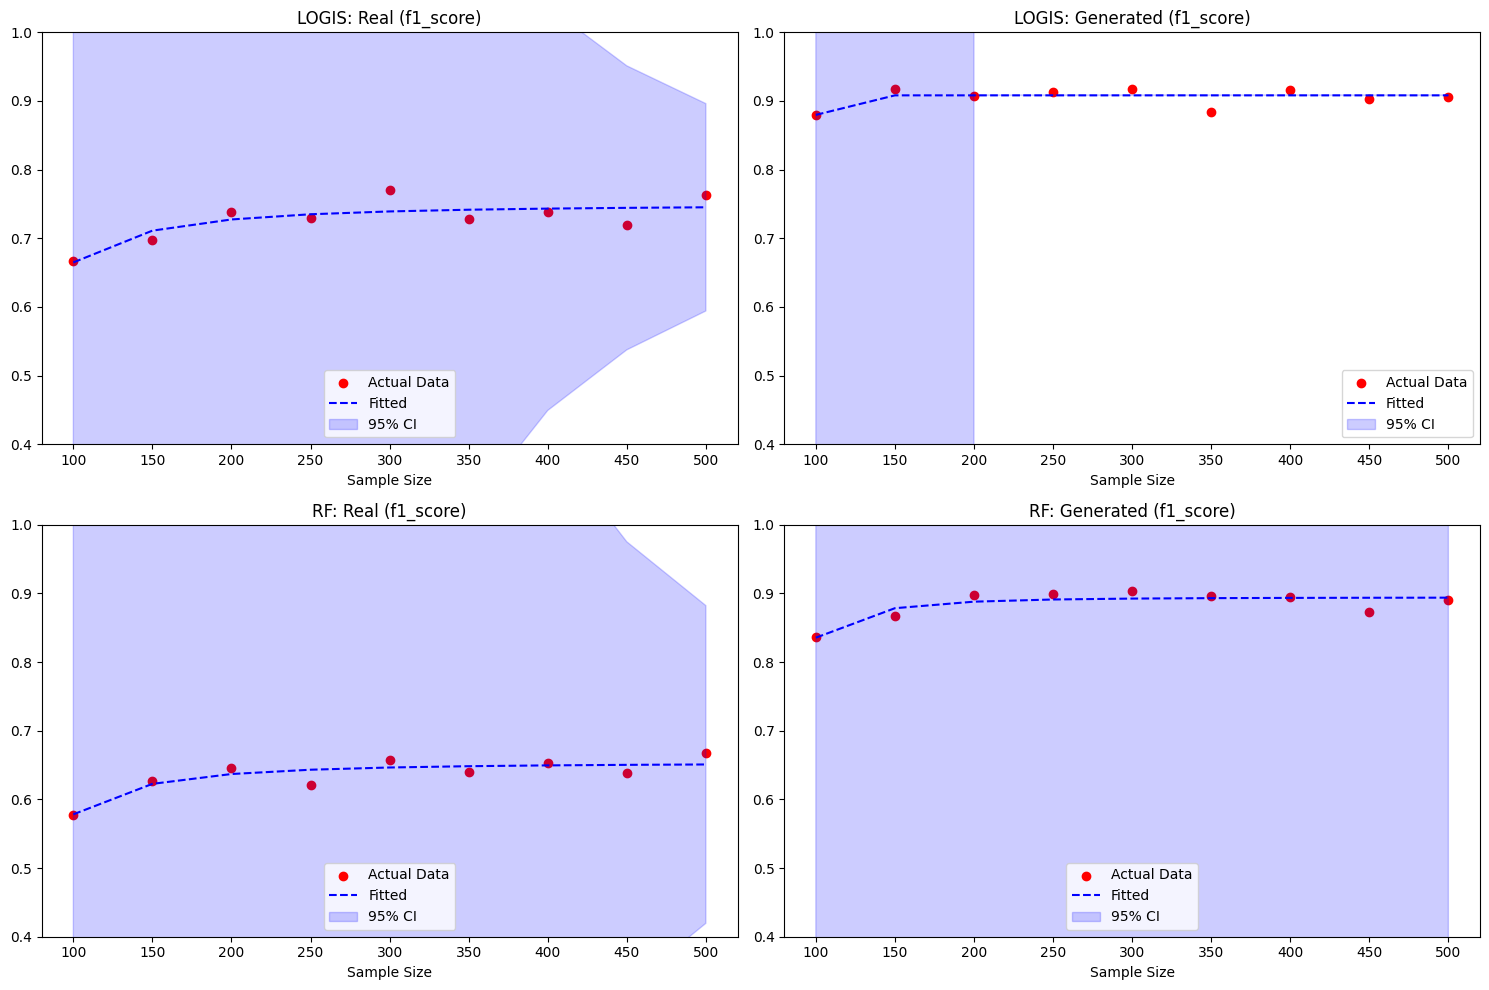

In [23]:
# Evaluate original and generated data directly from SyngResult
sample_sizes_syng = list(np.arange(100, 501, 50))

metrics_from_original = evaluate_sample_sizes(
    data=cvae_result,
    sample_sizes=sample_sizes_syng,
    which="original",
    n_draws=5,
    methods=["LOGIS", "RF"],
    apply_log=True,
)

metrics_from_generated = evaluate_sample_sizes(
    data=cvae_result,
    sample_sizes=sample_sizes_syng,
    which="generated",
    n_draws=5,
    methods=["LOGIS", "RF"],
    apply_log=True,
)

fig_syng = plot_sample_sizes(
    metric_real=metrics_from_original,
    metric_generated=metrics_from_generated,
    n_target=300,
    metric_name="f1_score",
)
plt.show()

## Notes

- `evaluate_sample_sizes` accepts either a DataFrame + `groups` or a `SyngResult`.
- `plot_sample_sizes` visualizes fitted learning curves for `f1_score`, `accuracy`, or `auc`.
- Increase `n_draws`, include more `sample_sizes`, and set `methods=None` for fuller analyses.